# Mackenzie River Outflow SSS and day of sea ice formation

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
from scipy.stats import t
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:34749")
client

<Client: 'tcp://127.0.0.1:34749' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

# open RHOAnoma zarr store - [fraction of sea ice, 0 to 1]
RHOAnoma_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/RHOAnoma_AVG_DAILY.ZARR/', s3_options)

In [7]:
# remove 2021 since we only have January and a few days in Feb that year
salt_day = SALT_zarr_day.SALT.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
theta_day = THETA_zarr_day.THETA.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
ice_day = SI_zarr_day.SIarea.sel(time=slice("2014","2020")).where(HH_grid.mask_basin.isel(k=0)==1)*100 # convert to percentage

# add reference density to density anomaly (RHOAnoma)
rhoConst = 1027.5 # reference density
density_day = RHOAnoma_zarr_day.RHOAnoma.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1) + rhoConst

In [8]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

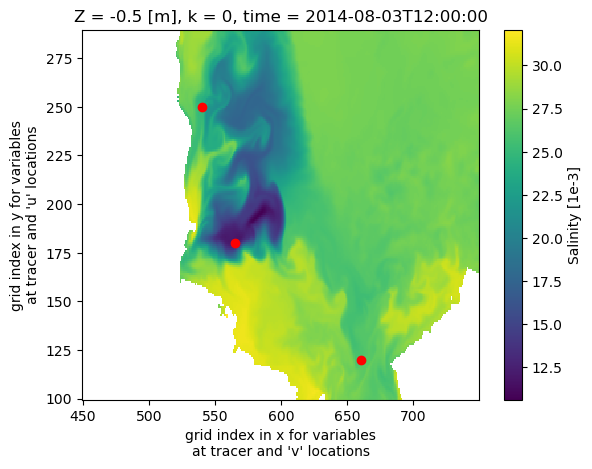

In [9]:
# plot Beaufort Sea area
salt_day.isel(k=0,i=slice(450,750),j=slice(100,290),time=200).plot();
plt.scatter(565,180,c='r');
plt.scatter(540,250,c='r');
plt.scatter(660,120,c='r');

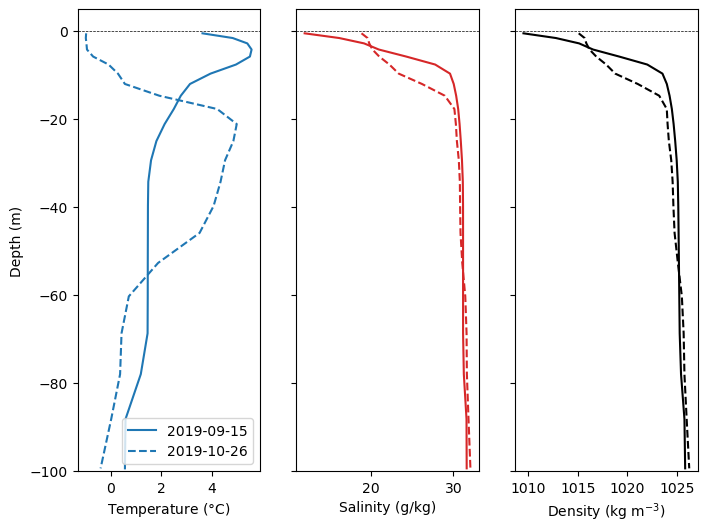

In [10]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,figsize=[8,6])

date = '2019-09-15'
theta_day.isel(i=565,j=180).sel(time=date).plot(ax=ax1,y='Z',color='tab:blue',label=date)
salt_day.isel(i=565,j=180).sel(time=date).plot(ax=ax2,y='Z',color='tab:red')
density_day.isel(i=565,j=180).sel(time=date).plot(ax=ax3,y='Z',color='k')

date = '2019-10-26'
theta_day.isel(i=565,j=180).sel(time=date).plot(ax=ax1,y='Z',color='tab:blue',linestyle='dashed',label=date)
salt_day.isel(i=565,j=180).sel(time=date).plot(ax=ax2,y='Z',color='tab:red',linestyle='dashed')
density_day.isel(i=565,j=180).sel(time=date).plot(ax=ax3,y='Z',color='k',linestyle='dashed')

for ax in (ax1,ax2,ax3):
    ax.set_ylim(-100,5)
    ax.axhline(y=0,c='k',linewidth=0.5,linestyle='dashed')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")

ax1.legend()
ax1.set_ylabel("Depth (m)")
ax1.set_xlabel("Temperature ($\degree$C)")
ax2.set_xlabel("Salinity (g/kg)")
ax3.set_xlabel("Density (kg m$^{-3}$)");

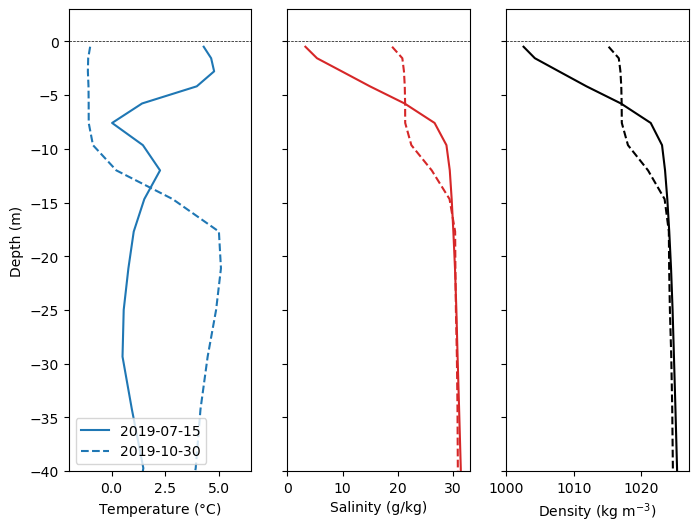

In [18]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,figsize=[8,6])

date = '2019-07-15'
theta_day.isel(i=565,j=180).sel(time=date).plot(ax=ax1,y='Z',color='tab:blue',label=date)
salt_day.isel(i=565,j=180).sel(time=date).plot(ax=ax2,y='Z',color='tab:red')
density_day.isel(i=565,j=180).sel(time=date).plot(ax=ax3,y='Z',color='k')

date = '2019-10-30'
theta_day.isel(i=565,j=180).sel(time=date).plot(ax=ax1,y='Z',color='tab:blue',linestyle='dashed',label=date)
salt_day.isel(i=565,j=180).sel(time=date).plot(ax=ax2,y='Z',color='tab:red',linestyle='dashed')
density_day.isel(i=565,j=180).sel(time=date).plot(ax=ax3,y='Z',color='k',linestyle='dashed')

for ax in (ax1,ax2,ax3):
    ax.set_ylim(-40,3)
    ax.axhline(y=0,c='k',linewidth=0.5,linestyle='dashed')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")

ax1.set_xlim(-2, 6.5)
ax2.set_xlim(0, 33)
ax3.set_xlim(1000, 1027)

ax1.legend(loc='lower left')
ax1.set_ylabel("Depth (m)")
ax1.set_xlabel("Temperature ($\degree$C)")
ax2.set_xlabel("Salinity (g/kg)")
ax3.set_xlabel("Density (kg m$^{-3}$)");

In [12]:
from matplotlib import animation

MovieWriter imagemagick unavailable; using Pillow instead.


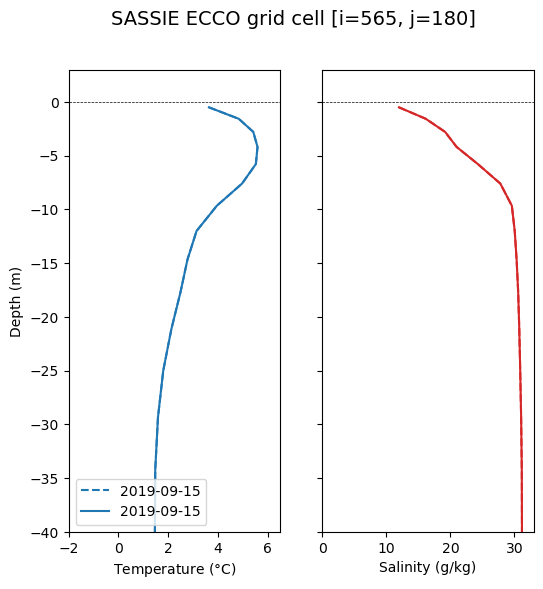

In [20]:
# Define start and end dates
dates = np.arange(np.datetime64('2019-09-15'), np.datetime64('2019-09-30') + np.timedelta64(1, 'D'))

# Create figure and subplots (now only 2 panels)
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=[6, 6])  # Adjusted figsize

# Add a title to the whole figure
fig.suptitle("SASSIE ECCO grid cell [i=565, j=180]", fontsize=14)

# Plot initial reference profile (dashed line)
initial_date = str(dates[0])
theta_day.isel(i=565, j=180).sel(time=initial_date).plot(ax=ax1, y='Z', color='tab:blue', linestyle='dashed', label=initial_date)
salt_day.isel(i=565, j=180).sel(time=initial_date).plot(ax=ax2, y='Z', color='tab:red', linestyle='dashed')

# Initialize empty lines for animation
line1, = ax1.plot([], [], color='tab:blue', label='')
line2, = ax2.plot([], [], color='tab:red')

def update(frame):
    current_date = str(dates[frame])
    
    # Update solid-line profiles for the current date
    theta = theta_day.isel(i=565, j=180).sel(time=current_date)
    salt = salt_day.isel(i=565, j=180).sel(time=current_date)
    
    line1.set_data(theta, theta['Z'])
    line1.set_label(current_date)
    line2.set_data(salt, salt['Z'])
    
    ax1.legend(loc='lower left')
    return line1, line2

# Formatting axes
for ax in (ax1, ax2):
    ax.set_ylim(-40, 3)
    ax.axhline(y=0, c='k', linewidth=0.5, linestyle='dashed')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("")

ax1.set_xlim(-2, 6.5)
ax2.set_xlim(0, 33)

ax1.set_ylabel("Depth (m)")
ax1.set_xlabel("Temperature ($\degree$C)")
ax2.set_xlabel("Salinity (g/kg)")

# Run animation
ani = animation.FuncAnimation(fig, update, frames=len(dates), interval=500, blit=False)

# Save animation
ani.save('profile_animation.gif', writer='imagemagick', fps=6)